[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/intensivedatacomp/WignerCamp2026/blob/master/AnomalyDetectionALTx/altx_anomaly.ipynb)

# `ALTx` for anomaly detection

In anomaly detection, we learn the characteristic **laws** (patterns) that govern **normal** behavior from training data. We then apply those laws to a test instance: subsequences that follow the normal laws produce small feature values, while subsequences that deviate from them produce large ones, revealing the location of anomalies.

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/Colab Notebooks/WignerCamp2025
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Running on Local computer


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

from functions import *

## Step 0: Define a training and test set
We generate synthetic time series using a simple **linear recursion rule** to represent normal behavior:
- The **normal** (training) instance follows the Fibonacci rule: $x_n = x_{n-1} + x_{n-2}$, with $w = [1, 1]$.
- The **test** instance starts from the same initial values, but has artificial anomalies injected at specific positions.

The goal is to recover those anomaly locations using only the laws extracted from the normal training instance.

In [3]:
no_anomaly_data = generate_recursive_array([1, 1], [1, 1], 7)
print(f"Train instance without anomalies: {no_anomaly_data}")
x = generate_recursive_array([1, 1], [1, 1], 7)
# Introducing an anomaly
error_locs = [0, 3]
for error_loc in error_locs:
    x[error_loc] += 5

print(f"Test instance 'x': {x}, which has anomali(es) at {error_locs}.")

Train instance without anomalies: tensor([ 1.,  1.,  2.,  3.,  5.,  8., 13.])
Test instance 'x': tensor([ 6.,  1.,  2.,  8.,  5.,  8., 13.]), which has anomali(es) at [0, 3].


## Step 1: Extracting the Laws
We extract **shapelet vectors** (or 'laws') from the **normal** training instance. Each law is a direction in space that characterizes how values change locally under normal conditions.

We use parameters $R=3$, $L=2$, $K=1$, meaning:
- $R=3$: the length of subsequences considered.
- $L=2$: the size of the matrix constructed from those subsequences.
- $K=1$: the shift between consecutive windows.

The shapelet vectors are obtained by computing the eigenvector of a symmetric matrix (constructed via time-delay embedding) corresponding to the **smallest eigenvalue**. Subsequences that obey the normal law are nearly orthogonal to this eigenvector, yielding a near-zero projection.

In [4]:
laws = extract_symmetric_laws(no_anomaly_data)
print(f"Laws from data without anomalies:\n{laws}")

Laws from data without anomalies:
tensor([[-0.8507, -0.8507, -0.8507, -0.8507, -0.8507],
        [ 0.5257,  0.5257,  0.5257,  0.5257,  0.5257]])


## Step 2: Embedding the test instance
We embed the test instance into overlapping 2D vectors (pairs of consecutive values). This constructs an input matrix $E$, where each row represents a local subsequence of the signal. Each row will be projected onto the normal laws in the next step.

In [5]:
embedded = embed_as_pairs(x)
norm = torch.norm(embedded, dim=1)
print(f"The embedded test instance: \n{embedded}")
embedded = embedded / norm.unsqueeze(1)

The embedded test instance: 
tensor([[ 6.,  1.],
        [ 1.,  2.],
        [ 2.,  8.],
        [ 8.,  5.],
        [ 5.,  8.],
        [ 8., 13.]])


## Step 3: Projection onto the Normal Laws (Matrix Multiplication)
We project each embedded subsequence onto the laws extracted from the normal training data. A subsequence that obeys the normal law lies nearly in the null space of the law matrix, producing a result close to zero. A subsequence that deviates from the normal law — i.e., an anomalous one — will instead produce a large projection value.

In [6]:
F = embedded @ laws
print(f"Multiplying with laws from gives:\n{F}")

Multiplying with laws from gives:
tensor([[-0.7526, -0.7526, -0.7526, -0.7526, -0.7526],
        [ 0.0898,  0.0898,  0.0898,  0.0898,  0.0898],
        [ 0.3037,  0.3037,  0.3037,  0.3037,  0.3037],
        [-0.4427, -0.4427, -0.4427, -0.4427, -0.4427],
        [-0.0050, -0.0050, -0.0050, -0.0050, -0.0050],
        [ 0.0019,  0.0019,  0.0019,  0.0019,  0.0019]])


## Step 4: Feature Calculation
From the projection result, we compute a simple **anomaly score** for each subsequence: the mean of the squared projection values (mean of $F^2$). 

- A **low score** means the subsequence is consistent with normal behavior.
- A **high score** means the subsequence deviates from the learned normal laws, flagging it as anomalous.

By comparing each score against a threshold, we can localize anomalies within the time series.

In [7]:
res_a = torch.mean(F**2, dim=1)
print(f"Taking the average over the laws give: {res_a}.")

Taking the average over the laws give: tensor([5.6648e-01, 8.0650e-03, 9.2246e-02, 1.9600e-01, 2.5250e-05, 3.6841e-06]).


Based on the threshold, the anomaly location(s) are: [0 3].


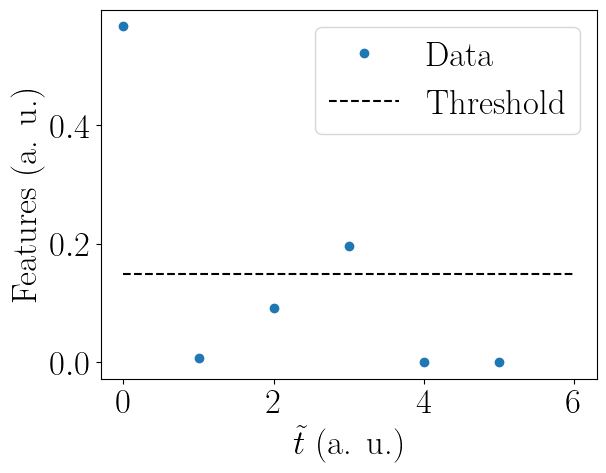

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sherif",
    "font.size": 25
})
threshold = 0.15
plt.plot(res_a, "o", label="Data")
plt.plot([0, res_a.shape[0]], [threshold, threshold], "--k", label="Threshold")
print(f"Based on the threshold, the anomaly location(s) are: {(res_a>threshold).nonzero(as_tuple=True)[0].numpy()}.")
plt.legend()
plt.xlabel("$\\tilde{t}$ (a. u.)")
plt.ylabel("Features (a. u.)")
plt.savefig("../img/anomaly_detection_example.pdf", bbox_inches="tight")

## Summary
In this minimal example, ALTx successfully detected and localized anomalies in the test sequence. The method:
- Extracted characteristic patterns (laws) from a **normal** training instance.
- Embedded the test sequence into overlapping local subsequences.
- Projected those subsequences onto the normal laws to obtain per-position anomaly scores.
- Compared the scores against a threshold to identify anomalous positions.

This illustrates how **ALTx builds an interpretable and efficient anomaly detection pipeline**, leveraging linear algebra and time-delay embeddings.

For more advanced applications, ALTx supports multiple channels, longer sequences, and more sophisticated feature extraction techniques such as percentiles and higher moments.